# Exploratory Data Analysis (EDA)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Load the three datasets, using the first column (patient id) as the index
datasets = {}
for name in ["metadata", "microbiome", "metabolome"]:
    df = pd.read_csv(f"train/{name}.csv")
    df = df.rename(columns={"Unnamed: 0": "patient_id"}).set_index("patient_id")
    datasets[name] = df
    print(f"{name:11s} -> {df.shape[0]} rows (patients), {df.shape[1]} features")

metadata    -> 1738 rows (patients), 5 features
microbiome  -> 1738 rows (patients), 170 features
metabolome  -> 1738 rows (patients), 102 features


## 1. Missing values per feature

In [26]:
# Number (and %) of missing values for every feature, per dataset
for name, df in datasets.items():
    n_rows = len(df)
    missing = df.isna().sum()
    summary = pd.DataFrame({
        "missing_count": missing,
        "missing_pct": (missing / n_rows * 100).round(2),
    }).sort_values("missing_count", ascending=False)

    print(f"\n===== {name} =====")
    print(f"features with at least one missing value: {(missing > 0).sum()} / {df.shape[1]}")
    print(f"total missing data points: {int(missing.sum())}")
    # show only features that actually have missing values (head if many)
    has_missing = summary[summary["missing_count"] > 0]
    display(has_missing if len(has_missing) <= 30 else has_missing.head(30))


===== metadata =====
features with at least one missing value: 3 / 5
total missing data points: 1443


,missing_count,missing_pct
BMI_C,491,28.25
GENDER,476,27.39
AGE,476,27.39



===== microbiome =====
features with at least one missing value: 170 / 170
total missing data points: 59160


,missing_count,missing_pct
CAG-83 sp001916855,348,20.02
Bacteroides fragilis,348,20.02
Bacteroides ovatus,348,20.02
Bacteroides stercoris,348,20.02
Bacteroides sp900552405,348,20.02
Bacteroides sp900761785,348,20.02
Bacteroides sp900755095,348,20.02
Bacteroides thetaiotaomicron,348,20.02
Bacteroides xylanisolvens,348,20.02
Bacteroides eggerthii,348,20.02



===== metabolome =====
features with at least one missing value: 102 / 102
total missing data points: 35496


,missing_count,missing_pct
"SERUM_ABS_1,5_anhydro_D_sorbitol",348,20.02
SERUM_ABS_hippuric_acid_2,348,20.02
SERUM_ABS_methyl_linolenate,348,20.02
SERUM_ABS_maltose_1,348,20.02
SERUM_ABS_malonic_acid_1,348,20.02
SERUM_ABS_linoleic_acid,348,20.02
SERUM_ABS_lauric_acid,348,20.02
SERUM_ABS_lactose_1,348,20.02
SERUM_ABS_lactamide_1,348,20.02
SERUM_ABS_indolepropionic_acid,348,20.02


## 2. Missing values per patient

In [27]:
# Missing values per row (patient), per dataset
missing_per_row = {}
for name, df in datasets.items():
    per_row = df.isna().sum(axis=1)
    missing_per_row[name] = per_row
    print(f"\n===== {name} ({df.shape[1]} features) =====")
    print(f"rows with at least one missing value: {(per_row > 0).sum()} / {len(df)}")
    print("missing-per-row stats:")
    print(per_row.describe()[["mean", "min", "25%", "50%", "75%", "max"]].round(2))
    print("distribution (how many patients have N missing values):")
    print(per_row.value_counts().sort_index())


===== metadata (5 features) =====
rows with at least one missing value: 491 / 1738
missing-per-row stats:
mean    0.83
min     0.00
25%     0.00
50%     0.00
75%     3.00
max     3.00
dtype: float64
distribution (how many patients have N missing values):
0    1247
1      15
3     476
Name: count, dtype: int64

===== microbiome (170 features) =====
rows with at least one missing value: 348 / 1738
missing-per-row stats:
mean     34.04
min       0.00
25%       0.00
50%       0.00
75%       0.00
max     170.00
dtype: float64
distribution (how many patients have N missing values):
0      1390
170     348
Name: count, dtype: int64

===== metabolome (102 features) =====
rows with at least one missing value: 348 / 1738
missing-per-row stats:
mean     20.42
min       0.00
25%       0.00
50%       0.00
75%       0.00
max     102.00
dtype: float64
distribution (how many patients have N missing values):
0      1390
102     348
Name: count, dtype: int64


## 3. Fully empty patients

In [28]:
# Rows that are completely empty (all feature values missing), per dataset
for name, df in datasets.items():
    all_missing_mask = df.isna().all(axis=1)
    n_empty = all_missing_mask.sum()
    print(f"{name:11s} -> {n_empty} fully-empty rows out of {len(df)} "
          f"({n_empty / len(df) * 100:.2f}%)")
    if n_empty > 0:
        print("   patient_ids:", list(df.index[all_missing_mask])[:20],
              "..." if n_empty > 20 else "")

# Patients with no data at all across ALL three datasets combined
all_ids = set().union(*[set(df.index) for df in datasets.values()])
empty_everywhere = [
    pid for pid in all_ids
    if all(pid not in df.index or df.loc[pid].isna().all() for df in datasets.values())
]
print(f"\nPatients with no data in ANY of the 3 datasets: {len(empty_everywhere)}")
print(empty_everywhere[:20], "..." if len(empty_everywhere) > 20 else "")

metadata    -> 0 fully-empty rows out of 1738 (0.00%)
microbiome  -> 348 fully-empty rows out of 1738 (20.02%)
   patient_ids: ['x20MCx1324', 'x10MCx1441', 'x11MCx2302', 'x10MCx3142', 'x30MCx3243', 'x10MCx1543', 'x30MCx1831', 'x14MCx2749', 'x10MCx1659', 'x30MCx1554', 'x20MCx1351', 'x30MCx2318', 'x14MCx1583', 'x20MCx1619', 'x20MCx2491', 'x14MCx3320', 'x30MCx3167', 'x20MCx1264', 'x10MCx1811', 'x30MCx1911'] ...
metabolome  -> 348 fully-empty rows out of 1738 (20.02%)
   patient_ids: ['x20MCx2221', 'x20MCx2697', 'x30MCx3423', 'x10MCx3057', 'x20MCx1241', 'x30MCx3353', 'x20MCx3182', 'x10MCx1483', 'x30MCx2724', 'x20MCx3264', 'x30MCx3215', 'x20MCx1825', 'x20MCx3299', 'x10MCx3407', 'x20MCx1599', 'x20MCx1812', 'x10MCx1937', 'x20MCx1341', 'x10MCx2862', 'x12MCx2380'] ...

Patients with no data in ANY of the 3 datasets: 0
[] 


## 4. Microbiome & metabolome completeness by PATGROUPFINAL_C

In [29]:
# For each PATGROUPFINAL_C group: how many patients have a full row vs a missing
# (empty) row in microbiome and in metabolome
group_stats = pd.DataFrame({
    "group": datasets["metadata"]["PATGROUPFINAL_C"],
    "mb_full": datasets["microbiome"].notna().all(axis=1),
    "mt_full": datasets["metabolome"].notna().all(axis=1),
})

per_group = group_stats.groupby("group").agg(
    n_patients=("mb_full", "size"),
    microbiome_full=("mb_full", "sum"),
    metabolome_full=("mt_full", "sum"),
)
per_group["microbiome_missing"] = per_group["n_patients"] - per_group["microbiome_full"]
per_group["metabolome_missing"] = per_group["n_patients"] - per_group["metabolome_full"]

per_group = per_group[[
    "n_patients",
    "microbiome_full", "microbiome_missing",
    "metabolome_full", "metabolome_missing",
]]
display(per_group)

,n_patients,microbiome_full,microbiome_missing,metabolome_full,metabolome_missing
group,,,,,
1,230,177,53,179,51
2a,239,192,47,193,46
2b,128,102,26,101,27
3,528,425,103,417,111
4,107,80,27,96,11
5,149,122,27,119,30
6,90,74,16,70,20
7,18,14,4,12,6
8,249,204,45,203,46


## 5. Microbiome & metabolome completeness by CENTER_C

In [30]:
# For each CENTER_C: how many patients have a full row vs a missing (empty) row
# in microbiome and in metabolome
center_stats = pd.DataFrame({
    "center": datasets["metadata"]["CENTER_C"],
    "mb_full": datasets["microbiome"].notna().all(axis=1),
    "mt_full": datasets["metabolome"].notna().all(axis=1),
})

per_center = center_stats.groupby("center").agg(
    n_patients=("mb_full", "size"),
    microbiome_full=("mb_full", "sum"),
    metabolome_full=("mt_full", "sum"),
)
per_center["microbiome_missing"] = per_center["n_patients"] - per_center["microbiome_full"]
per_center["metabolome_missing"] = per_center["n_patients"] - per_center["metabolome_full"]

per_center = per_center[[
    "n_patients",
    "microbiome_full", "microbiome_missing",
    "metabolome_full", "metabolome_missing",
]]
display(per_center)

,n_patients,microbiome_full,microbiome_missing,metabolome_full,metabolome_missing
center,,,,,
Danemark,476,370,106,391,85
France,743,604,139,589,154
Germany,519,416,103,410,109


In [31]:
# Compare the sets of fully-empty patients between microbiome and metabolome
empty_mb = set(datasets["microbiome"].index[datasets["microbiome"].isna().all(axis=1)])
empty_mt = set(datasets["metabolome"].index[datasets["metabolome"].isna().all(axis=1)])

print(f"empty in microbiome : {len(empty_mb)}")
print(f"empty in metabolome : {len(empty_mt)}")
print(f"in BOTH (same patients) : {len(empty_mb & empty_mt)}")
print(f"only microbiome empty   : {len(empty_mb - empty_mt)}")
print(f"only metabolome empty   : {len(empty_mt - empty_mb)}")
print(f"union (distinct patients empty in >=1): {len(empty_mb | empty_mt)}")

empty in microbiome : 348
empty in metabolome : 348
in BOTH (same patients) : 0
only microbiome empty   : 348
only metabolome empty   : 348
union (distinct patients empty in >=1): 696


## 6. Patients with complete data

In [32]:
# Patients whose row is fully populated (no missing values) in each dataset
complete = {name: set(df.index[df.notna().all(axis=1)]) for name, df in datasets.items()}
for name, df in datasets.items():
    print(f"{name:11s} complete rows: {len(complete[name])} / {len(df)}")

full_all = complete["metadata"] & complete["microbiome"] & complete["metabolome"]
print(f"\npatients with FULL data in ALL three datasets: {len(full_all)}")
print(f"  metadata + microbiome  : {len(complete['metadata'] & complete['microbiome'])}")
print(f"  metadata + metabolome  : {len(complete['metadata'] & complete['metabolome'])}")
print(f"  microbiome + metabolome: {len(complete['microbiome'] & complete['metabolome'])}")
print(f"  metadata + microbiome + metabolome: {len(full_all)}")

metadata    complete rows: 1247 / 1738
microbiome  complete rows: 1390 / 1738
metabolome  complete rows: 1390 / 1738

patients with FULL data in ALL three datasets: 749
  metadata + microbiome  : 1009
  metadata + metabolome  : 987
  microbiome + metabolome: 1042
  metadata + microbiome + metabolome: 749


## 7. Disease distribution, demographics & metadata missingness

Total patients with a disease label: 1738


,group,disease,n_patients,pct
0,1,Metabolic syndrome,230,13.2
1,2a,Severe obesity,239,13.8
2,2b,Severe obesity (bariatric),128,7.4
3,3,Type 2 diabetes,528,30.4
4,4,Acute CAD event,107,6.2
5,5,Chronic CAD,149,8.6
6,6,Chronic CAD + heart failure,90,5.2
7,7,Congestive heart failure,18,1.0
8,8,Healthy control,249,14.3


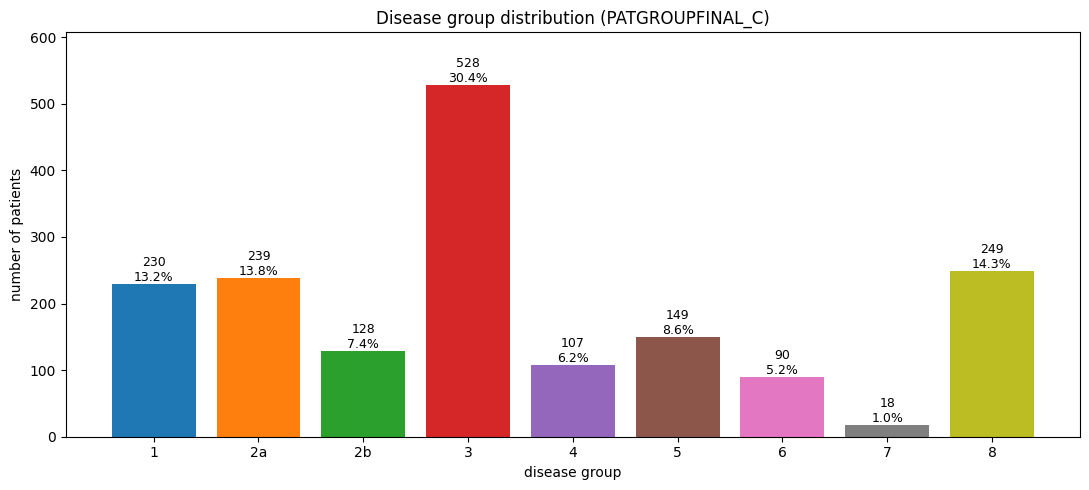

In [33]:

DISEASE_LABELS = {
    "1":  "Metabolic syndrome",
    "2a": "Severe obesity",
    "2b": "Severe obesity (bariatric)",
    "3":  "Type 2 diabetes",
    "4":  "Acute CAD event",
    "5":  "Chronic CAD",
    "6":  "Chronic CAD + heart failure",
    "7":  "Congestive heart failure",
    "8":  "Healthy control",
}
GROUP_ORDER = ["1", "2a", "2b", "3", "4", "5", "6", "7", "8"]

# Work on a copy with the group as a clean string column.
meta = datasets["metadata"].copy()
meta["PATGROUPFINAL_C"] = meta["PATGROUPFINAL_C"].astype(str)


def disease_distribution(meta, group_col="PATGROUPFINAL_C"):
    """Return a per-disease table with sample size and percentage of the cohort."""
    counts = meta[group_col].value_counts().reindex(GROUP_ORDER).fillna(0).astype(int)
    dist = pd.DataFrame({
        "group": counts.index,
        "disease": [DISEASE_LABELS[g] for g in counts.index],
        "n_patients": counts.values,
    })
    dist["pct"] = (dist["n_patients"] / dist["n_patients"].sum() * 100).round(1)
    return dist.reset_index(drop=True)


dist = disease_distribution(meta)
print(f"Total patients with a disease label: {dist['n_patients'].sum()}")
display(dist)

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette("tab10", len(dist))
bars = ax.bar(dist["group"], dist["n_patients"], color=colors)
for b, n, p in zip(bars, dist["n_patients"], dist["pct"]):
    ax.text(b.get_x() + b.get_width() / 2, n, f"{n}\n{p}%",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Disease group distribution (PATGROUPFINAL_C)")
ax.set_xlabel("disease group")
ax.set_ylabel("number of patients")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

Metadata columns containing missing values:


,missing_count,missing_pct
BMI_C,491,28.3
GENDER,476,27.4
AGE,476,27.4


Columns with NO missing values: ['PATGROUPFINAL_C', 'CENTER_C']


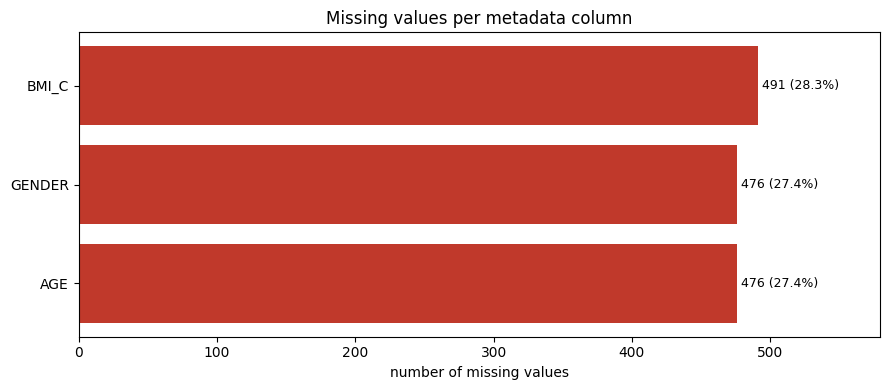


Missing AGE/GENDER/BMI broken down by center (reveals the Denmark-driven gap):


,GENDER,AGE,BMI_C
CENTER_C,,,
Danemark,476,476,476
France,0,0,15
Germany,0,0,0


In [34]:

def missing_columns(df):
    """Return only the columns that have >= 1 missing value, with count and %."""
    miss = df.isna().sum()
    out = pd.DataFrame({
        "missing_count": miss,
        "missing_pct": (miss / len(df) * 100).round(1),
    })
    return out[out["missing_count"] > 0].sort_values("missing_count", ascending=False)


meta_missing = missing_columns(datasets["metadata"])
print("Metadata columns containing missing values:")
display(meta_missing)
print("Columns with NO missing values:",
      list(datasets["metadata"].columns[datasets["metadata"].notna().all()]))

fig, ax = plt.subplots(figsize=(9, 4))
rows = meta_missing.iloc[::-1]
ax.barh(rows.index, rows["missing_count"], color="#c0392b")
for i, (c, p) in enumerate(zip(rows["missing_count"], rows["missing_pct"])):
    ax.text(c, i, f" {c} ({p}%)", va="center", fontsize=9)
ax.set_title("Missing values per metadata column")
ax.set_xlabel("number of missing values")
ax.margins(x=0.18)
plt.tight_layout()
plt.show()

# How does metadata missingness relate to recruitment center?
print("\nMissing AGE/GENDER/BMI broken down by center "
      "(reveals the Denmark-driven gap):")
miss_by_center = (datasets["metadata"]
                  .assign(CENTER_C=datasets["metadata"]["CENTER_C"])
                  .groupby("CENTER_C")[["GENDER", "AGE", "BMI_C"]]
                  .apply(lambda g: g.isna().sum()))
display(miss_by_center)

# Note: microbiome/metabolome columns are never partially missing -- a patient row is
# either fully present or fully empty (see sections 1-3), so column-level missingness
# is a metadata-only phenomenon.

## 8. PATGROUPFINAL_C composition by center, gender, BMI and age

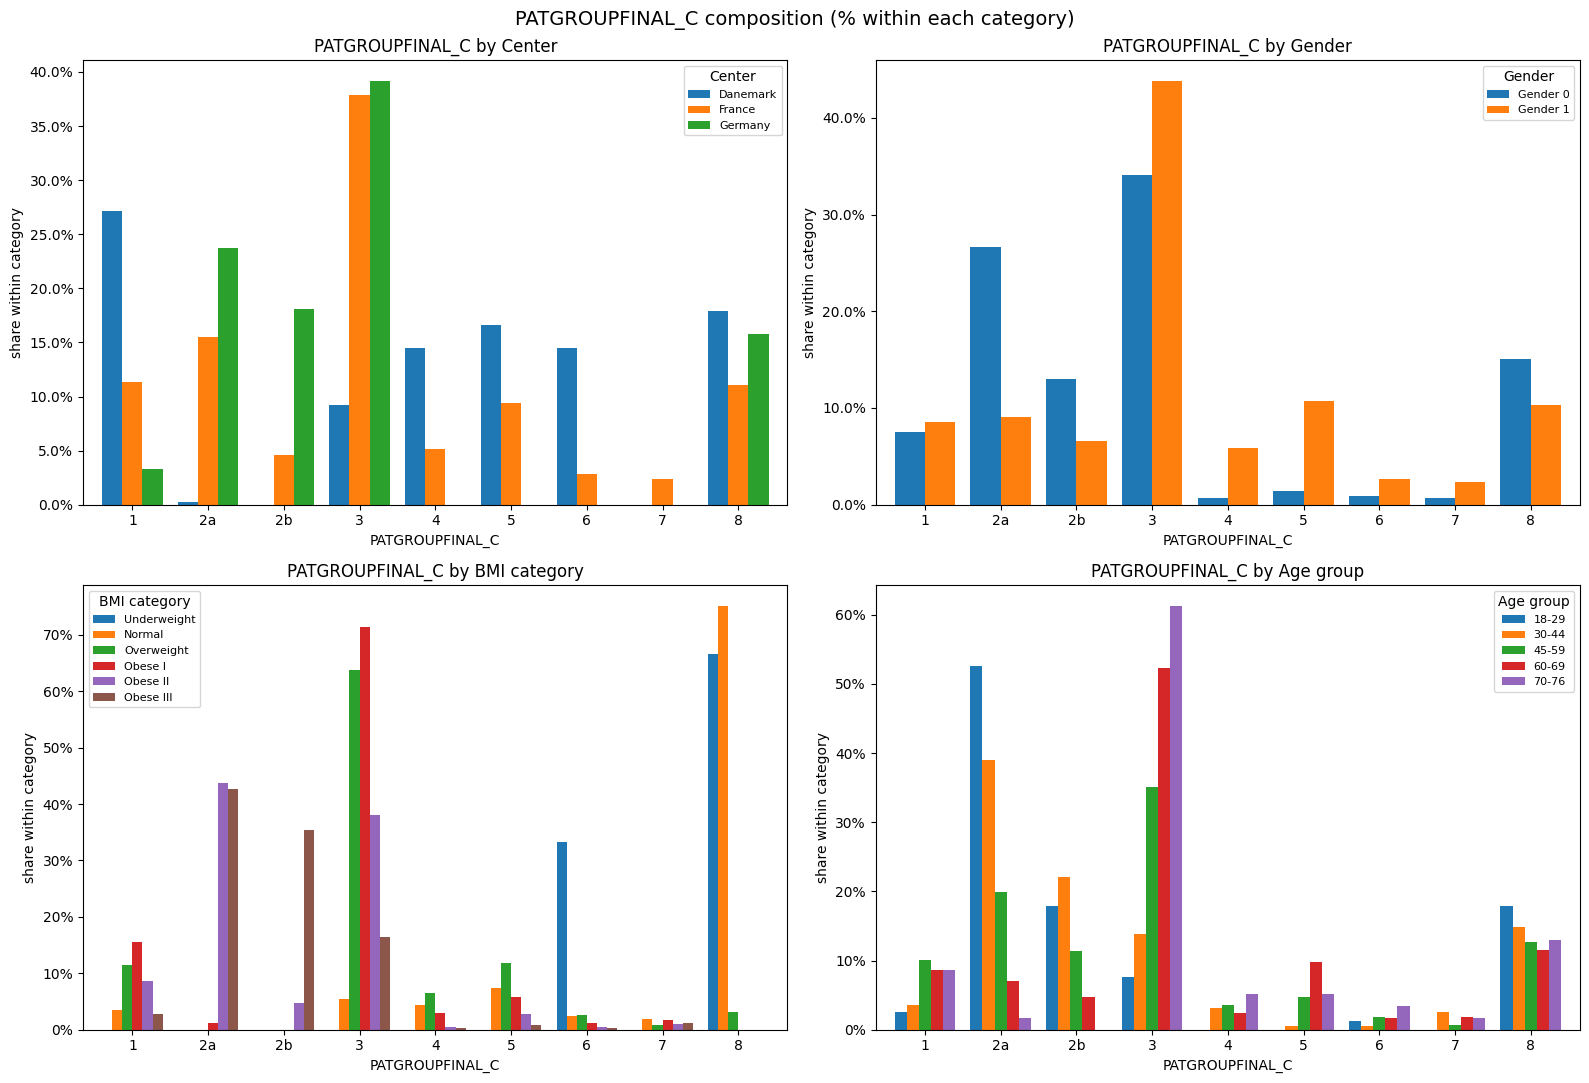


===== PATGROUPFINAL_C by Center (count and % within category) =====


CENTER_C,Danemark,France,Germany
PATGROUPFINAL_C,,,
1,129 (27.1%),84 (11.3%),17 (3.3%)
2a,1 (0.2%),115 (15.5%),123 (23.7%)
2b,0 (0.0%),34 (4.6%),94 (18.1%)
3,44 (9.2%),281 (37.8%),203 (39.1%)
4,69 (14.5%),38 (5.1%),0 (0.0%)
5,79 (16.6%),70 (9.4%),0 (0.0%)
6,69 (14.5%),21 (2.8%),0 (0.0%)
7,0 (0.0%),18 (2.4%),0 (0.0%)
8,85 (17.9%),82 (11.0%),82 (15.8%)



===== PATGROUPFINAL_C by Gender (count and % within category) =====


GENDER_LABEL,Gender 0,Gender 1
PATGROUPFINAL_C,,
1,53 (7.5%),48 (8.6%)
2a,187 (26.6%),51 (9.1%)
2b,91 (13.0%),37 (6.6%)
3,239 (34.0%),245 (43.8%)
4,5 (0.7%),33 (5.9%)
5,10 (1.4%),60 (10.7%)
6,6 (0.9%),15 (2.7%)
7,5 (0.7%),13 (2.3%)
8,106 (15.1%),58 (10.4%)



===== PATGROUPFINAL_C by BMI category (count and % within category) =====


BMI_GROUP,Underweight,Normal,Overweight,Obese I,Obese II,Obese III
PATGROUPFINAL_C,,,,,,
1,0 (0.0%),7 (3.4%),30 (11.5%),37 (15.5%),18 (8.6%),9 (2.7%)
2a,0 (0.0%),0 (0.0%),0 (0.0%),3 (1.3%),92 (43.8%),141 (42.7%)
2b,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),10 (4.8%),117 (35.5%)
3,0 (0.0%),11 (5.4%),167 (63.7%),170 (71.4%),80 (38.1%),54 (16.4%)
4,0 (0.0%),9 (4.4%),17 (6.5%),7 (2.9%),1 (0.5%),1 (0.3%)
5,0 (0.0%),15 (7.4%),31 (11.8%),14 (5.9%),6 (2.9%),3 (0.9%)
6,1 (33.3%),5 (2.5%),7 (2.7%),3 (1.3%),1 (0.5%),1 (0.3%)
7,0 (0.0%),4 (2.0%),2 (0.8%),4 (1.7%),2 (1.0%),4 (1.2%)
8,2 (66.7%),153 (75.0%),8 (3.1%),0 (0.0%),0 (0.0%),0 (0.0%)



===== PATGROUPFINAL_C by Age group (count and % within category) =====


AGE_GROUP,18-29,30-44,45-59,60-69,70-76
PATGROUPFINAL_C,,,,,
1,2 (2.6%),7 (3.6%),45 (10.1%),37 (8.7%),10 (8.6%)
2a,41 (52.6%),76 (39.0%),89 (19.9%),30 (7.0%),2 (1.7%)
2b,14 (17.9%),43 (22.1%),51 (11.4%),20 (4.7%),0 (0.0%)
3,6 (7.7%),27 (13.8%),157 (35.1%),223 (52.3%),71 (61.2%)
4,0 (0.0%),6 (3.1%),16 (3.6%),10 (2.3%),6 (5.2%)
5,0 (0.0%),1 (0.5%),21 (4.7%),42 (9.9%),6 (5.2%)
6,1 (1.3%),1 (0.5%),8 (1.8%),7 (1.6%),4 (3.4%)
7,0 (0.0%),5 (2.6%),3 (0.7%),8 (1.9%),2 (1.7%)
8,14 (17.9%),29 (14.9%),57 (12.8%),49 (11.5%),15 (12.9%)


In [35]:
# Build derived groupings for age and BMI, then plot PATGROUPFINAL_C composition
meta = datasets["metadata"].copy()

# Age -> 5 groups
age_bins = [18, 30, 45, 60, 70, 77]
age_labels = ["18-29", "30-44", "45-59", "60-69", "70-76"]
meta["AGE_GROUP"] = pd.cut(meta["AGE"], bins=age_bins, labels=age_labels, right=False)

# BMI -> WHO categories
bmi_bins = [0, 18.5, 25, 30, 35, 40, np.inf]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese I", "Obese II", "Obese III"]
meta["BMI_GROUP"] = pd.cut(meta["BMI_C"], bins=bmi_bins, labels=bmi_labels, right=False)

# Gender (encoded 0/1 in the data)
meta["GENDER_LABEL"] = meta["GENDER"].map({0.0: "Gender 0", 1.0: "Gender 1"})

group_order = ["1", "2a", "2b", "3", "4", "5", "6", "7", "8"]
breakdowns = {
    "CENTER_C": "Center",
    "GENDER_LABEL": "Gender",
    "BMI_GROUP": "BMI category",
    "AGE_GROUP": "Age group",
}

from matplotlib.ticker import PercentFormatter

crosstabs = {}
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, (col, title) in zip(axes.ravel(), breakdowns.items()):
    # Percentage of each breakdown category (e.g. each center) that falls in
    # each PATGROUPFINAL_C group -> columns sum to 100%
    pct = pd.crosstab(meta["PATGROUPFINAL_C"], meta[col],
                      normalize="columns").reindex(group_order) * 100
    crosstabs[title] = pct
    pct.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(f"PATGROUPFINAL_C by {title}")
    ax.set_xlabel("PATGROUPFINAL_C")
    ax.set_ylabel("share within category")
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title=title, fontsize=8)

fig.suptitle("PATGROUPFINAL_C composition (% within each category)", fontsize=14)
plt.tight_layout()
plt.show()

# Print counts + percentages for each breakdown so small (less significant)
# cells are easy to spot. Each cell shows "count (pct%)"; the Total row is the
# absolute number of patients (N) in that category.
for col, title in breakdowns.items():
    print(f"\n===== PATGROUPFINAL_C by {title} (count and % within category) =====")
    counts = pd.crosstab(meta["PATGROUPFINAL_C"], meta[col]).reindex(group_order)
    pct = crosstabs[title]

    combined = counts.astype(int).astype(str) + " (" + pct.round(1).astype(str) + "%)"
    combined.loc["N (total)"] = counts.sum(axis=0).astype(int).astype(str)
    display(combined)